# Visualisations pour la présentation

Graphes intuitifs et colorés pour la présentation du projet.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

from src.envs import LargeTaxiEnv
from src.agent import DQNTaxiAgent
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

# Palette de couleurs harmonisée
COLORS = {
    'primary': '#2E86AB',      # Bleu
    'success': '#06A77D',      # Vert
    'warning': '#F77F00',      # Orange
    'danger': '#D62828',       # Rouge
    'light': '#EAE2B7',        # Beige
    'dark': '#1B1B1B',         # Noir
}

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#F5F5F5'

2026-03-16 12:39:13.390947: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Charger le modèle et évaluer

In [2]:
env = LargeTaxiEnv(render_mode=None, grid_width=15, grid_height=10, n_passengers=2)
agent = DQNTaxiAgent(env=env)
agent.load("../training/checkpoints/dqn_taxi_final.zip")

def evaluate_agent(agent, env, n_episodes=200):
    rewards = []
    steps = []
    successes = 0
    
    for ep in range(n_episodes):
        obs, _ = env.reset()
        total_reward = 0
        step_count = 0
        done = False
        
        while not done:
            action = agent.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            step_count += 1
            done = terminated or truncated
        
        rewards.append(total_reward)
        steps.append(step_count)
        if terminated:
            successes += 1
    
    return rewards, steps, successes / n_episodes * 100

print("Évaluation en cours (200 épisodes)...")
rewards, steps, success_rate = evaluate_agent(agent, env, n_episodes=200)
print(f"Taux de succès: {success_rate:.1f}%")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
[DQN] Modèle chargé ← ../training/checkpoints/dqn_taxi_final.zip
Évaluation en cours (200 épisodes)...
Taux de succès: 0.0%


## 2. Graphe 1 : Distribution des récompenses (style présentation)

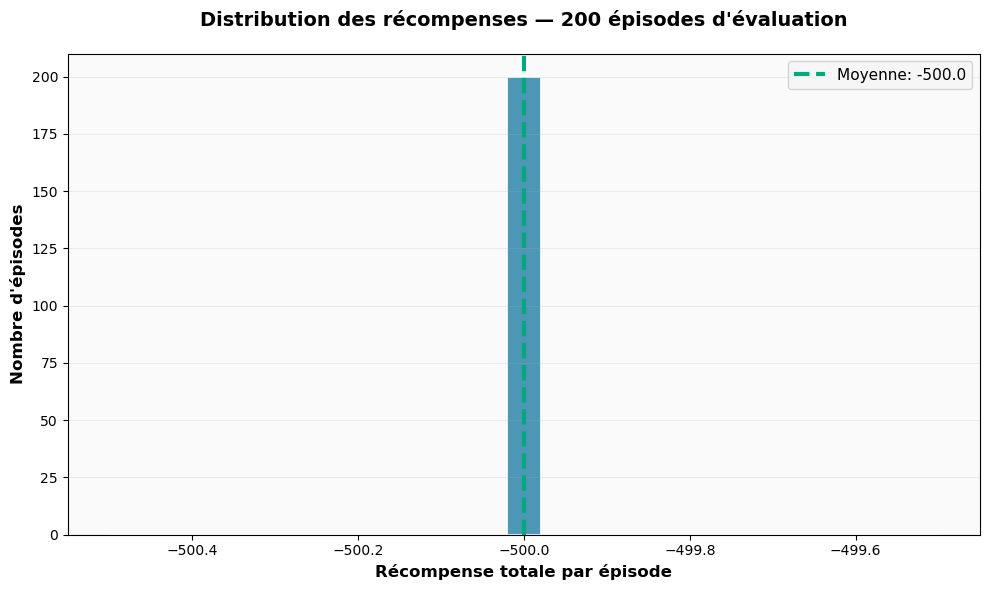

Sauvegardé → ../logs/presentation_rewards_distribution.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

n, bins, patches_hist = ax.hist(rewards, bins=25, color=COLORS['primary'], 
                                  edgecolor='white', alpha=0.85, linewidth=1.5)

mean_reward = np.mean(rewards)
ax.axvline(mean_reward, color=COLORS['success'], linewidth=3, 
           label=f'Moyenne: {mean_reward:.1f}', linestyle='--')

ax.set_xlabel('Récompense totale par épisode', fontsize=12, fontweight='bold')
ax.set_ylabel('Nombre d\'épisodes', fontsize=12, fontweight='bold')
ax.set_title('Distribution des récompenses — 200 épisodes d\'évaluation', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.2, axis='y')
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('../logs/presentation_rewards_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Sauvegardé → ../logs/presentation_rewards_distribution.png")

## 3. Graphe 2 : Distribution des pas (optimisation)

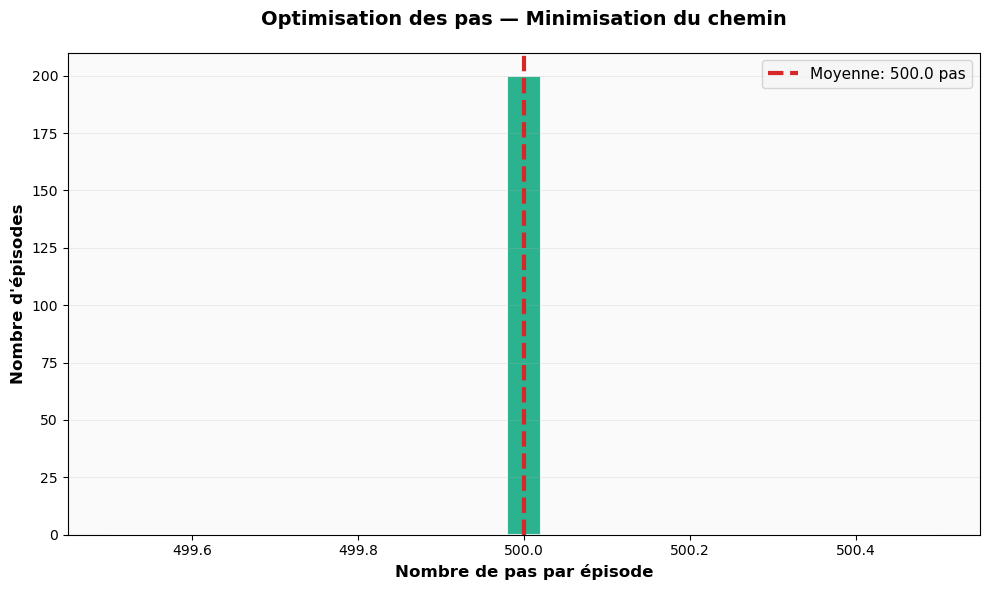

Sauvegardé → ../logs/presentation_steps_distribution.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

n, bins, patches_hist = ax.hist(steps, bins=25, color=COLORS['success'], 
                                  edgecolor='white', alpha=0.85, linewidth=1.5)

mean_steps = np.mean(steps)
ax.axvline(mean_steps, color=COLORS['danger'], linewidth=3, 
           label=f'Moyenne: {mean_steps:.1f} pas', linestyle='--')

ax.set_xlabel('Nombre de pas par épisode', fontsize=12, fontweight='bold')
ax.set_ylabel('Nombre d\'épisodes', fontsize=12, fontweight='bold')
ax.set_title('Optimisation des pas — Minimisation du chemin', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.2, axis='y')
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('../logs/presentation_steps_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Sauvegardé → ../logs/presentation_steps_distribution.png")

## 4. Graphe 3 : Tableau de synthèse KPI

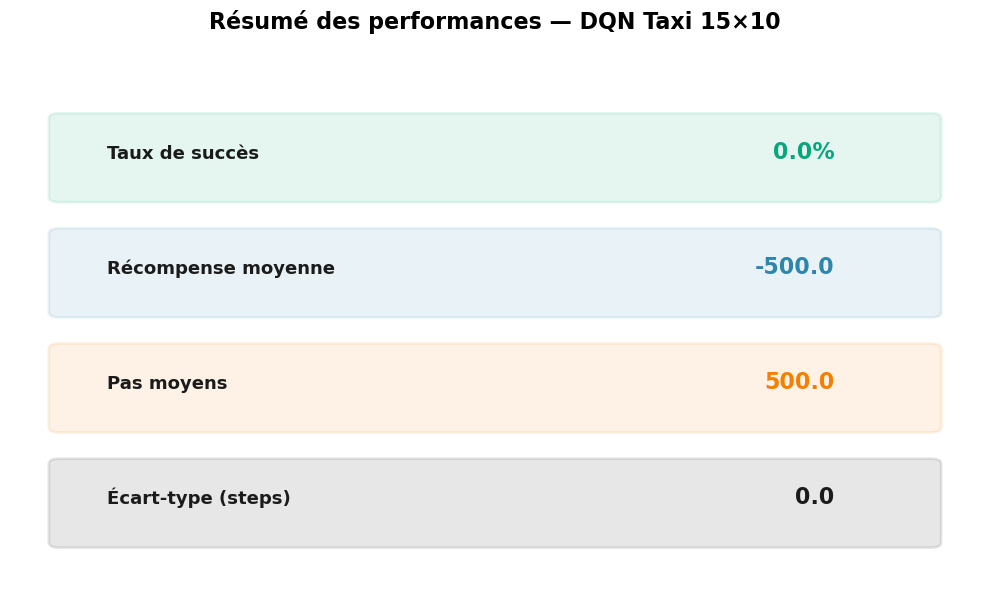

Sauvegardé → ../logs/presentation_kpi_summary.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

# Données KPI
kpis = [
    ('Taux de succès', f'{success_rate:.1f}%', COLORS['success']),
    ('Récompense moyenne', f'{np.mean(rewards):.1f}', COLORS['primary']),
    ('Pas moyens', f'{np.mean(steps):.1f}', COLORS['warning']),
    ('Écart-type (steps)', f'{np.std(steps):.1f}', COLORS['dark']),
]

y_pos = 0.85
for label, value, color in kpis:
    # Boîte colorée
    rect = patches.FancyBboxPatch((0.05, y_pos - 0.12), 0.9, 0.15,
                                   boxstyle="round,pad=0.01",
                                   edgecolor=color, facecolor=color, alpha=0.1,
                                   linewidth=2, transform=ax.transAxes)
    ax.add_patch(rect)
    
    # Texte
    ax.text(0.1, y_pos - 0.045, label, fontsize=13, fontweight='bold',
            transform=ax.transAxes, color=COLORS['dark'])
    ax.text(0.85, y_pos - 0.045, value, fontsize=16, fontweight='bold',
            transform=ax.transAxes, color=color, ha='right')
    
    y_pos -= 0.22

ax.set_title('Résumé des performances — DQN Taxi 15×10', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../logs/presentation_kpi_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("Sauvegardé → ../logs/presentation_kpi_summary.png")

## 5. Graphe 4 : Heatmap de visites (couverture de l'espace)

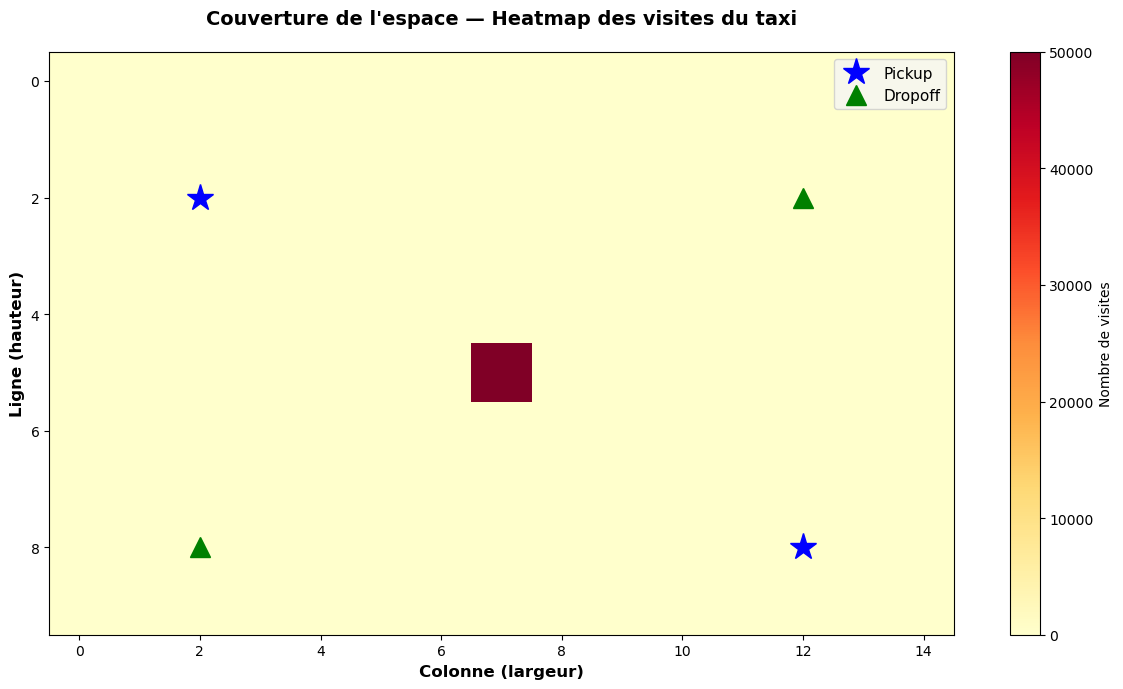

Sauvegardé → ../logs/presentation_visit_heatmap.png


In [6]:
# Tracker les visites du taxi
visit_grid = np.zeros((10, 15))

for ep in range(100):
    obs, _ = env.reset()
    done = False
    
    while not done:
        # Extraire position du taxi (premiers 2 éléments de l'observation)
        taxi_x, taxi_y = int(obs[0]), int(obs[1])
        visit_grid[taxi_y, taxi_x] += 1
        
        action = agent.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

fig, ax = plt.subplots(figsize=(12, 7))

im = ax.imshow(visit_grid, cmap='YlOrRd', aspect='auto', origin='upper')

# Marquer les zones de pickup/dropoff
pickup_zones = [(2, 2), (12, 8)]
dropoff_zones = [(12, 2), (2, 8)]

for i, (x, y) in enumerate(pickup_zones):
    ax.plot(x, y, 'b*', markersize=20, label='Pickup' if i == 0 else '')

for i, (x, y) in enumerate(dropoff_zones):
    ax.plot(x, y, 'g^', markersize=15, label='Dropoff' if i == 0 else '')

ax.set_xlabel('Colonne (largeur)', fontsize=12, fontweight='bold')
ax.set_ylabel('Ligne (hauteur)', fontsize=12, fontweight='bold')
ax.set_title('Couverture de l\'espace — Heatmap des visites du taxi', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper right')

cbar = plt.colorbar(im, ax=ax, label='Nombre de visites')

plt.tight_layout()
plt.savefig('../logs/presentation_visit_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Sauvegardé → ../logs/presentation_visit_heatmap.png")

## 6. Graphe 5 : Comparaison Récompense vs Pas

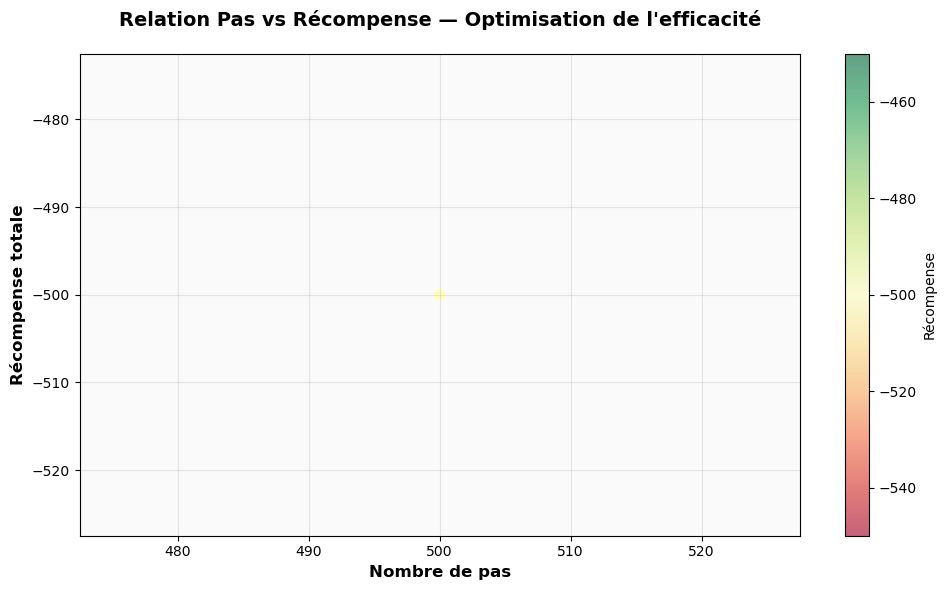

Sauvegardé → ../logs/presentation_reward_vs_steps.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(steps, rewards, alpha=0.6, s=80, c=rewards, 
                     cmap='RdYlGn', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Nombre de pas', fontsize=12, fontweight='bold')
ax.set_ylabel('Récompense totale', fontsize=12, fontweight='bold')
ax.set_title('Relation Pas vs Récompense — Optimisation de l\'efficacité', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#FAFAFA')

cbar = plt.colorbar(scatter, ax=ax, label='Récompense')

plt.tight_layout()
plt.savefig('../logs/presentation_reward_vs_steps.png', dpi=300, bbox_inches='tight')
plt.show()
print("Sauvegardé → ../logs/presentation_reward_vs_steps.png")

In [8]:
env.close()
print("\nTous les graphes de présentation ont été générés !")


Tous les graphes de présentation ont été générés !
